In [48]:
import os
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression

In [49]:
path=os.getcwd()
files = os.listdir(path+"\\Big Data Analysis")
files

['20002001.csv',
 '20012002.csv',
 '20022003.csv',
 '20032004.csv',
 '20042005.csv',
 '20052006.csv',
 '20062007.csv',
 '20072008.csv',
 '20082009.csv',
 '20092010.csv',
 '20102011.csv',
 '20112012.csv',
 '20122013.csv',
 '20132014.csv',
 '20142015.csv',
 '20152016.csv',
 '20162017.csv',
 '20172018.csv',
 '20182019.csv',
 '20192020.csv',
 'Notes.txt']

In [50]:
files_csv = ["Big Data Analysis\\"+f for f in files if f[-3:] == 'csv']
files_csv

['Big Data Analysis\\20002001.csv',
 'Big Data Analysis\\20012002.csv',
 'Big Data Analysis\\20022003.csv',
 'Big Data Analysis\\20032004.csv',
 'Big Data Analysis\\20042005.csv',
 'Big Data Analysis\\20052006.csv',
 'Big Data Analysis\\20062007.csv',
 'Big Data Analysis\\20072008.csv',
 'Big Data Analysis\\20082009.csv',
 'Big Data Analysis\\20092010.csv',
 'Big Data Analysis\\20102011.csv',
 'Big Data Analysis\\20112012.csv',
 'Big Data Analysis\\20122013.csv',
 'Big Data Analysis\\20132014.csv',
 'Big Data Analysis\\20142015.csv',
 'Big Data Analysis\\20152016.csv',
 'Big Data Analysis\\20162017.csv',
 'Big Data Analysis\\20172018.csv',
 'Big Data Analysis\\20182019.csv',
 'Big Data Analysis\\20192020.csv']

In [51]:
li=[]
r=0
c=[]
df=pd.DataFrame()
S=[]
for filename in files_csv:
    print(filename)
    temp = pd.read_csv(filename, index_col=None, encoding = "ISO-8859-1", ) #, error_bad_lines=False, warn_bad_lines=True
    S=df.columns
    df=pd.concat([df,temp], axis=0)
    SB=df.columns
    print(len(df.columns))
    print(list(set(SB)-set(S)))

Big Data Analysis\20002001.csv
45
['HC', 'HBP', 'HST', 'ABP', 'Div', 'HS', 'WHH', 'IWD', 'Attendance', 'IWA', 'HTR', 'HF', 'FTR', 'GBD', 'WHA', 'IWH', 'FTHG', 'GBA', 'HHW', 'Date', 'AwayTeam', 'FTAG', 'AS', 'AST', 'HomeTeam', 'SBA', 'GBH', 'SBH', 'HTHG', 'SBD', 'LBH', 'AO', 'AF', 'AR', 'HO', 'AHW', 'HTAG', 'LBD', 'LBA', 'HY', 'HR', 'AC', 'WHD', 'Referee', 'AY']
Big Data Analysis\20012002.csv
48
['SYD', 'SYH', 'SYA']
Big Data Analysis\20022003.csv
58
['B365<2.5', 'B365H', 'SOD', 'B365>2.5', 'SOH', 'B365D', 'GB<2.5', 'SOA', 'GB>2.5', 'B365A']
Big Data Analysis\20032004.csv
67
['GBAH', 'GBAHA', 'B365AHH', 'GBAHH', 'LBAHH', 'LBAHA', 'B365AHA', 'LBAH', 'B365AH']
Big Data Analysis\20042005.csv
70
['BWH', 'BWA', 'BWD']
Big Data Analysis\20052006.csv
94
['BbMxH', 'BbOU', 'BbAvAHA', 'BbMxAHH', 'BbAvA', 'BbMx<2.5', 'BbMxD', 'BbMx>2.5', 'SJD', 'BbAv<2.5', 'BbAHh', 'Bb1X2', 'SJH', 'SJA', 'BbAvAHH', 'BbAvH', 'VCA', 'BbMxAHA', 'BbAvD', 'VCH', 'BbAH', 'BbAv>2.5', 'VCD', 'BbMxA']
Big Data Analysis\200

In [52]:
df.reset_index(inplace=True)

In [53]:
df.tail(10)

,index,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
7499,278,E0,07/03/2020,Liverpool,Bournemouth,2.0,1.0,H,2.0,1.0,...,2.98,-2.00,2.02,1.77,2.13,1.79,2.15,1.93,2.08,1.80
7500,279,E0,07/03/2020,Arsenal,West Ham,1.0,0.0,H,0.0,0.0,...,2.46,-1.00,2.07,1.72,2.17,1.78,2.22,1.86,2.10,1.79
7501,280,E0,07/03/2020,Crystal Palace,Watford,1.0,0.0,H,1.0,0.0,...,1.62,0.00,1.92,1.98,1.93,1.99,1.95,2.06,1.89,1.98
7502,281,E0,07/03/2020,Sheffield United,Norwich,1.0,0.0,H,1.0,0.0,...,1.77,-0.75,1.85,2.05,1.88,2.05,1.90,2.09,1.86,2.02
7503,282,E0,07/03/2020,Southampton,Newcastle,0.0,1.0,A,0.0,0.0,...,1.80,-0.75,1.95,1.95,1.98,1.95,1.98,1.99,1.95,1.93
7504,283,E0,07/03/2020,Wolves,Brighton,0.0,0.0,D,0.0,0.0,...,1.74,-0.75,1.98,1.92,2.01,1.92,2.03,1.99,1.94,1.93
7505,284,E0,07/03/2020,Burnley,Tottenham,1.0,1.0,D,1.0,0.0,...,1.74,0.00,1.95,1.95,1.96,1.97,2.00,2.01,1.94,1.92
7506,285,E0,08/03/2020,Chelsea,Everton,4.0,0.0,H,2.0,0.0,...,2.13,-0.50,1.85,2.05,1.88,2.04,2.00,2.11,1.86,2.01
7507,286,E0,08/03/2020,Man United,Man City,2.0,0.0,H,1.0,0.0,...,1.97,0.75,1.87,2.03,1.85,2.07,1.91,2.11,1.87,2.01
7508,287,E0,09/03/2020,Leicester,Aston Villa,4.0,0.0,H,1.0,0.0,...,2.28,-1.00,1.85,2.05,1.88,2.05,1.91,2.08,1.86,2.01


In [54]:
del[df['index']]

In [55]:
filt= df['Date'].str[-3]=='/'

In [56]:
df.loc[filt]['Date']

0       19/08/00
1       19/08/00
2       19/08/00
3       19/08/00
4       19/08/00
          ...   
6456    21/05/17
6457    21/05/17
6458    21/05/17
6459    21/05/17
6460    21/05/17
Name: Date, Length: 5940, dtype: object

In [57]:
df.loc[filt,'Date']= df.loc[filt,'Date'].str[:-2]+'20'+df.loc[filt,'Date'].str[-2:]

In [58]:
df['Date']=pd.to_datetime(df['Date'], format= '%d/%m/%Y')

In [59]:
df['DayName']=df['Date'].dt.day_name()

In [60]:
df.describe()

,FTHG,FTAG,HTHG,HTAG,Attendance,HS,AS,HST,AST,HHW,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
count,7508.000000,7508.000000,7508.000000,7508.000000,759.000000,7508.000000,7508.000000,7508.000000,7508.000000,760.000000,...,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000
mean,1.528769,1.139718,0.681406,0.498801,33718.504611,13.544885,10.557272,6.281700,4.841369,0.342105,...,2.211597,-0.308160,1.944410,1.963750,1.961111,1.974757,2.015243,2.029583,1.935313,1.952535
std,1.294658,1.130987,0.830349,0.715114,12108.931821,5.231931,4.514801,3.350475,2.817954,0.608517,...,0.529475,0.958346,0.138414,0.104617,0.152462,0.107878,0.150694,0.112072,0.137273,0.100927
min,0.000000,0.000000,0.000000,0.000000,14651.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.460000,-3.250000,1.670000,1.270000,1.710000,1.300000,1.800000,1.300000,1.700000,1.280000
25%,1.000000,0.000000,0.000000,0.000000,24707.000000,10.000000,7.000000,4.000000,3.000000,0.000000,...,1.820000,-0.750000,1.870000,1.900000,1.880000,1.890000,1.930000,1.950000,1.860000,1.880000
50%,1.000000,1.000000,0.000000,0.000000,32910.000000,13.000000,10.000000,6.000000,4.000000,0.000000,...,2.110000,-0.250000,1.950000,1.970000,1.960000,1.980000,2.000000,2.040000,1.930000,1.950000
75%,2.000000,2.000000,1.000000,1.000000,39834.000000,17.000000,13.000000,8.000000,6.000000,1.000000,...,2.430000,0.250000,2.020000,2.040000,2.030000,2.050000,2.070000,2.100000,2.000000,2.020000
max,9.000000,9.000000,5.000000,5.000000,67683.000000,43.000000,30.000000,24.000000,20.000000,4.000000,...,5.010000,3.000000,3.550000,2.200000,3.930000,2.290000,3.950000,2.300000,3.660000,2.240000


In [61]:
df.shape

(7509, 162)

In [62]:
df['Div'].value_counts(dropna=False)

E0     7508
NaN       1
Name: Div, dtype: int64

In [63]:
#Delete
del df['Div']

In [64]:
df.sort_values(by=['Date'],inplace=True)

In [65]:
#df.head().to_csv('sotun.csv')

In [66]:
set(df['AwayTeam'].unique())==set(df['HomeTeam'].unique())

True

In [67]:
filt=df['Date'].dt.year==2000
df.loc[filt, 'Date'].dt.month.value_counts(dropna=False)

12    56
9     47
11    40
10    33
8     29
Name: Date, dtype: int64

In [68]:
filt1= df['Date'].dt.month > 7
filt2= df['Date'].dt.month < 6
df.loc[filt1,'Season']= df.loc[filt1,'Date'].dt.year-2000
df.loc[filt2,'Season']= df.loc[filt2,'Date'].dt.year-2000-1

In [69]:
filt1= df['FTR']=='H'
filt3= df['FTR']=='D'
filt2= df['FTR']=='A'
df.loc[filt1, 'Final_result']= 1
df.loc[filt3, 'Final_result']= 2
df.loc[filt2, 'Final_result']= 3

In [70]:
#Delete
del df['FTR']
del df['DayName']

In [71]:
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,HTR,Attendance,Referee,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season,Final_result
0,2000-08-19,Charlton,Man City,4.0,0.0,2.0,0.0,H,20043.0,Rob Harris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0
1,2000-08-19,Chelsea,West Ham,4.0,2.0,1.0,0.0,H,34914.0,Graham Barber,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0
2,2000-08-19,Coventry,Middlesbrough,1.0,3.0,1.0,1.0,D,20624.0,Barry Knight,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0
3,2000-08-19,Derby,Southampton,2.0,2.0,1.0,2.0,A,27223.0,Andy D'Urso,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.0
4,2000-08-19,Leeds,Everton,2.0,0.0,2.0,0.0,H,40010.0,Dermot Gallagher,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0


In [72]:
#Rename columns
df = df.rename(columns = {'FTHG':'Final_Home_goals', 'FTAG':'Final_Away_goals', 'HTR':'Half_Time_Result','HTHG':'Half_Time_Home_Goals',
                          'HTAG':'Half_Time_Away_Goals', 'HS':'Home_Shots', 'AS':'Away_Shots','HST':'Home_Shots_Target', 'AST':'Away_Shots_Target', 'Attendance':'Crowd_Attendance',
                          'HHW':'Home_Woodwork', 'AHW':'Away_Woodwork', 'HC':'Home_Corners', 'AC':'Away_Corners', 'HF':'Home_Fouls', 'AF':'Away_Fouls',
                          'HFKC':'Home_Free_Kicks', 'AFKC':'Away_Free_Kicks', 'HO':'Home_Offsides', 'AO':'Away_Offsides', 'HY':'Home_Yellow_Cards', 'AY':'Away_Yellow_Cards', 
                           'HR':'Home_Red_Cards', 'AR':'Away_Red_Cards', 'HBP':'Home_Bookings_Points', 'ABP':'Away_Bookings_Points'})


In [73]:
df.head(2)

,Date,HomeTeam,AwayTeam,Final_Home_goals,Final_Away_goals,Half_Time_Home_Goals,Half_Time_Away_Goals,Half_Time_Result,Crowd_Attendance,Referee,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season,Final_result
0,2000-08-19,Charlton,Man City,4.0,0.0,2.0,0.0,H,20043.0,Rob Harris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0
1,2000-08-19,Chelsea,West Ham,4.0,2.0,1.0,0.0,H,34914.0,Graham Barber,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0


In [74]:
filt1= df['Half_Time_Result']=='H'
filt3= df['Half_Time_Result']=='D'
filt2= df['Half_Time_Result']=='A'
df.loc[filt1, 'Half_Time_Result']= 1
df.loc[filt3, 'Half_Time_Result']= 2
df.loc[filt2, 'Half_Time_Result']= 3

In [75]:
df['Time'].value_counts(dropna=False)

NaN      7221
15:00     119
14:00      34
17:30      31
16:30      29
12:30      29
20:00      21
19:30      15
20:15       5
19:45       4
18:00       1
Name: Time, dtype: int64

In [76]:
df.loc[5700,:]

Date                NaT
HomeTeam            NaN
AwayTeam            NaN
Final_Home_goals    NaN
Final_Away_goals    NaN
                   ... 
MaxCAHA             NaN
AvgCAHH             NaN
AvgCAHA             NaN
Season              NaN
Final_result        NaN
Name: 5700, Length: 161, dtype: object

In [77]:
df.drop(axis=0, index=5700, inplace=True)

In [78]:
df.shape

(7508, 161)

In [79]:
df.loc[df['Final_result']==3,'Date'].count()

2128

In [80]:
df.loc[df['Final_result']==1,'Date'].count()

3486

In [81]:
count = np.array([3486, 2128])
nobs = np.array([7508, 7508])
stat, pval = proportions_ztest(count, nobs)
print('{0:0.3f}'.format(pval))


0.000


In [82]:
df.tail(5)

,Date,HomeTeam,AwayTeam,Final_Home_goals,Final_Away_goals,Half_Time_Home_Goals,Half_Time_Away_Goals,Half_Time_Result,Crowd_Attendance,Referee,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season,Final_result
7503,2020-03-07,Southampton,Newcastle,0.0,1.0,0.0,0.0,2,NaN,G Scott,...,1.95,1.95,1.98,1.95,1.98,1.99,1.95,1.93,19.0,3.0
7505,2020-03-07,Burnley,Tottenham,1.0,1.0,1.0,0.0,1,NaN,J Moss,...,1.95,1.95,1.96,1.97,2.00,2.01,1.94,1.92,19.0,2.0
7507,2020-03-08,Man United,Man City,2.0,0.0,1.0,0.0,1,NaN,M Dean,...,1.87,2.03,1.85,2.07,1.91,2.11,1.87,2.01,19.0,1.0
7506,2020-03-08,Chelsea,Everton,4.0,0.0,2.0,0.0,1,NaN,K Friend,...,1.85,2.05,1.88,2.04,2.00,2.11,1.86,2.01,19.0,1.0
7508,2020-03-09,Leicester,Aston Villa,4.0,0.0,1.0,0.0,1,NaN,M Oliver,...,1.85,2.05,1.88,2.05,1.91,2.08,1.86,2.01,19.0,1.0


In [83]:
filt1=df['Final_result']==1
filt2=df['Final_result']==3
df.loc[filt1,'Winner']= df.loc[filt1]['HomeTeam']
df.loc[filt2,'Winner']= df.loc[filt2]['AwayTeam']

In [84]:
filt1= df['Final_result']==1
filt2= df['Final_result']==3
filt3= df['Final_result']==2
df.loc[filt1,'Home_score']= 3
df.loc[filt2,'Home_score']= 0
df.loc[filt3,'Home_score']= 1
df.loc[filt1,'Away_score']= 0
df.loc[filt2,'Away_score']= 3
df.loc[filt3,'Away_score']= 1

In [85]:
df.groupby(['Season','HomeTeam']).agg({'Home_score':'sum'}) 

Home_score
Season HomeTeam               
0.0    Arsenal            48.0
       Aston Villa        32.0
       Bradford           19.0
       Charlton           38.0
       Chelsea            42.0
...                        ...
19.0   Southampton        14.0
       Tottenham          26.0
       Watford            17.0
       West Ham           15.0
       Wolves             22.0

[400 rows x 1 columns]

In [86]:
df.groupby(['Season','HomeTeam'])['Home_score'].sum()

Season  HomeTeam   
0.0     Arsenal        48.0
        Aston Villa    32.0
        Bradford       19.0
        Charlton       38.0
        Chelsea        42.0
                       ... 
19.0    Southampton    14.0
        Tottenham      26.0
        Watford        17.0
        West Ham       15.0
        Wolves         22.0
Name: Home_score, Length: 400, dtype: float64

In [87]:
df.groupby(['Season','AwayTeam']).agg({'Away_score':'sum'})

Away_score
Season AwayTeam               
0.0    Arsenal            22.0
       Aston Villa        22.0
       Bradford            7.0
       Charlton           14.0
       Chelsea            19.0
...                        ...
19.0   Southampton        20.0
       Tottenham          15.0
       Watford            10.0
       West Ham           12.0
       Wolves             21.0

[400 rows x 1 columns]

In [100]:
ss = pd.DataFrame(df.groupby(['Season','HomeTeam'])['Home_score'].sum() + df.groupby(['Season','AwayTeam'])['Away_score'].sum())

In [101]:
ss = ss.rename(columns = {0:'Total_team_scores_per_season'})

In [102]:
ss

Total_team_scores_per_season
Season HomeTeam                                 
0.0    Arsenal                              70.0
       Aston Villa                          54.0
       Bradford                             26.0
       Charlton                             52.0
       Chelsea                              61.0
...                                          ...
19.0   Southampton                          34.0
       Tottenham                            41.0
       Watford                              27.0
       West Ham                             27.0
       Wolves                               43.0

[400 rows x 1 columns]

In [103]:
ss['default_rank']= ss.groupby(['Season'])['Total_team_scores_per_season'].rank(ascending=False)

In [104]:
ss.loc[0,'default_rank']

HomeTeam
Arsenal           2.0
Aston Villa       8.0
Bradford         20.0
Charlton          9.5
Chelsea           6.0
Coventry         18.5
Derby            15.5
Everton          15.5
Ipswich           5.0
Leeds             4.0
Leicester        13.0
Liverpool         3.0
Man City         18.5
Man United        1.0
Middlesbrough    15.5
Newcastle        11.0
Southampton       9.5
Sunderland        7.0
Tottenham        12.0
West Ham         15.5
Name: default_rank, dtype: float64

In [105]:
ss.head()

Total_team_scores_per_season  default_rank
Season HomeTeam                                               
0.0    Arsenal                              70.0           2.0
       Aston Villa                          54.0           8.0
       Bradford                             26.0          20.0
       Charlton                             52.0           9.5
       Chelsea                              61.0           6.0

In [110]:
sr= ss.drop(axis=1, columns='Total_team_scores_per_season')

In [111]:
sr

default_rank
Season HomeTeam                 
0.0    Arsenal               2.0
       Aston Villa           8.0
       Bradford             20.0
       Charlton              9.5
       Chelsea               6.0
...                          ...
19.0   Southampton          14.0
       Tottenham             8.0
       Watford              17.0
       West Ham             17.0
       Wolves                6.5

[400 rows x 1 columns]

In [112]:
sr= sr.unstack()

In [113]:
sr

default_rank                                                    \
HomeTeam      Arsenal Aston Villa Birmingham Blackburn Blackpool Bolton   
Season                                                                    
0.0               2.0         8.0        NaN       NaN       NaN    NaN   
1.0               1.0         8.5        NaN      10.0       NaN   16.5   
2.0               2.0        16.0       13.5       6.0       NaN   17.0   
3.0               1.0         5.5       10.0      15.0       NaN    7.5   
4.0               2.0        10.0       12.0      15.0       NaN    5.5   
5.0               4.0        16.0       18.0       6.0       NaN    8.0   
6.0               3.5        11.0        NaN      10.0       NaN    7.0   
7.0               3.0         6.0       19.0       7.0       NaN   16.0   
8.0               4.0         6.0        NaN      14.0       NaN   14.0   
9.0               3.0         6.0        9.5       9.5       NaN   14.0   
10.0              4.0         9.0       18.5      15.0      18.5   13.0   
11.0              3.0        16.0        NaN      19.0       NaN   18.0   
12.0              4.0        15.0        NaN       NaN       NaN    NaN   
13.0              4.0        14.5        NaN       NaN       NaN    NaN   
14.0              3.0        16.5        NaN       NaN       NaN    NaN   
15.0              2.0        20.0        NaN       NaN       NaN    NaN   
16.0              5.0         NaN        NaN       NaN       NaN    NaN   
17.0              6.0         NaN        NaN       NaN       NaN    NaN   
18.0              5.0         NaN        NaN       NaN       NaN    NaN   
19.0              9.0        19.0        NaN       NaN       NaN    NaN   

                                                                         \
HomeTeam Bournemouth Bradford Brighton Burnley Cardiff Charlton Chelsea   
Season                                                                    
0.0              NaN     20.0      NaN     NaN     NaN      9.5     6.0   
1.0              NaN      NaN      NaN     NaN     NaN     13.5     6.0   
2.0              NaN      NaN      NaN     NaN     NaN     11.5     4.0   
3.0              NaN      NaN      NaN     NaN     NaN      7.5     2.0   
4.0              NaN      NaN      NaN     NaN     NaN     11.0     1.0   
5.0              NaN      NaN      NaN     NaN     NaN     13.0     1.0   
6.0              NaN      NaN      NaN     NaN     NaN     19.0     2.0   
7.0              NaN      NaN      NaN     NaN     NaN      NaN     2.0   
8.0              NaN      NaN      NaN     NaN     NaN      NaN     3.0   
9.0              NaN      NaN      NaN    18.5     NaN      NaN     1.0   
10.0             NaN      NaN      NaN     NaN     NaN      NaN     2.5   
11.0             NaN      NaN      NaN     NaN     NaN      NaN     6.0   
12.0             NaN      NaN      NaN     NaN     NaN      NaN     3.0   
13.0             NaN      NaN      NaN     NaN    20.0      NaN     3.0   
14.0             NaN      NaN      NaN    19.0     NaN      NaN     1.0   
15.0            15.5      NaN      NaN     NaN     NaN      NaN    10.0   
16.0             8.5      NaN      NaN    16.5     NaN      NaN     1.0   
17.0            11.0      NaN     15.0     7.0     NaN      NaN     5.0   
18.0            13.5      NaN     17.0    15.0    18.0      NaN     3.0   
19.0            17.0      NaN     15.0    10.5     NaN      NaN     4.0   

                                                                          \
HomeTeam Coventry Crystal Palace Derby Everton Fulham Huddersfield  Hull   
Season                                                                     
0.0          18.5            NaN  15.5    15.5    NaN          NaN   NaN   
1.0           NaN            NaN  19.0    15.0   13.5          NaN   NaN   
2.0           NaN            NaN   NaN     7.0   13.5          NaN   NaN   
3.0           NaN            NaN   NaN    17.0    9.0          NaN   NaN   
4.0           NaN        

In [114]:
pd.set_option('display.max_columns',170)

In [115]:
srt12= sr.dropna(thresh= 12, axis= 'columns')

In [116]:
srt12

default_rank                                                        \
HomeTeam      Arsenal Aston Villa Chelsea Everton Fulham Liverpool Man City   
Season                                                                        
0.0               2.0         8.0     6.0    15.5    NaN       3.0     18.5   
1.0               1.0         8.5     6.0    15.0   13.5       2.0      NaN   
2.0               2.0        16.0     4.0     7.0   13.5       5.0      9.0   
3.0               1.0         5.5     2.0    17.0    9.0       4.0     16.0   
4.0               2.0        10.0     1.0     4.0   13.5       5.5      8.5   
5.0               4.0        16.0     1.0    11.0   12.0       3.0     15.0   
6.0               3.5        11.0     2.0     6.0   16.0       3.5     14.0   
7.0               3.0         6.0     2.0     5.0   17.5       4.0      9.0   
8.0               4.0         6.0     3.0     5.0    7.0       2.0     10.0   
9.0               3.0         6.0     1.0     8.0   12.0       7.0      5.0   
10.0              4.0         9.0     2.5     7.0    8.0       6.0      2.5   
11.0              3.0        16.0     6.0     7.0    8.5       8.5      1.5   
12.0              4.0        15.0     3.0     6.0   12.0       7.0      2.0   
13.0              4.0        14.5     3.0     5.0   19.0       2.0      1.0   
14.0              3.0        16.5     1.0    11.5    NaN       6.0      2.0   
15.0              2.0        20.0    10.0    11.5    NaN       8.0      4.5   
16.0              5.0         NaN     1.0     7.0    NaN       4.0      3.0   
17.0              6.0         NaN     5.0     8.0    NaN       4.0      1.0   
18.0              5.0         NaN     3.0     8.0   19.0       2.0      1.0   
19.0              9.0        19.0     4.0    12.0    NaN       1.0      2.0   

                                                                          \
HomeTeam Man United Newcastle Southampton Sunderland Tottenham West Brom   
Season                                                                     
0.0             1.0      11.0         9.5        7.0      12.0       NaN   
1.0             3.0       4.0        11.5       16.5       8.5       NaN   
2.0             1.0       3.0         8.0       20.0      10.0      19.0   
3.0             3.0       5.5        12.0        NaN      13.5       NaN   
4.0             3.0      13.5        20.0        NaN       8.5      17.0   
5.0             2.0       7.0         NaN       20.0       5.0      19.0   
6.0             1.0      13.0         NaN        NaN       5.0       NaN   
7.0             1.0      12.0         NaN       15.0      11.0       NaN   
8.0             1.0      18.0         NaN       16.0       8.5      19.5   
9.0             2.0       NaN         NaN       13.0       4.0       NaN   
10.0            1.0      13.0         NaN       10.5       5.0      10.5   
11.0            1.5       5.0         NaN       13.5       4.0      11.0   
12.0            1.0      15.0        15.0       17.0       5.0       8.0   
13.0            7.0      10.0         8.0       14.5       6.0      17.0   
14.0            4.0      15.0         7.0       16.5       5.0      13.0   
15.0            4.5      18.0         6.0       17.0       3.0      14.0   
16.0            6.0       NaN         8.5       20.0       2.0      10.5   
17.0            2.0      11.0        17.0        NaN       3.0      20.0   
18.0            6.0      13.5        16.0        NaN       4.0       NaN   
19.0            5.0      13.0        14.0        NaN       8.0       NaN   

                   
HomeTeam West Ham  
Season             
0.0          15.5  
1.0           7.0  
2.0          18.0  
3.0           NaN  
4.0           NaN  
5.0           9.0  
6.0          15.0  
7.0          10.0  
8.0           8.5  
9.0          17.0  
10.0         20.0  
11.0          NaN  
12.0          9.5  
13.0         13.0  
14.0         11.5  
15.0          7.0  
16.0         10.5  
17.0         13.0  
18.0          9.5  
19

Keep only the columns with at least 'thresh' non-NA values.

<Figure size 432x288 with 0 Axes>

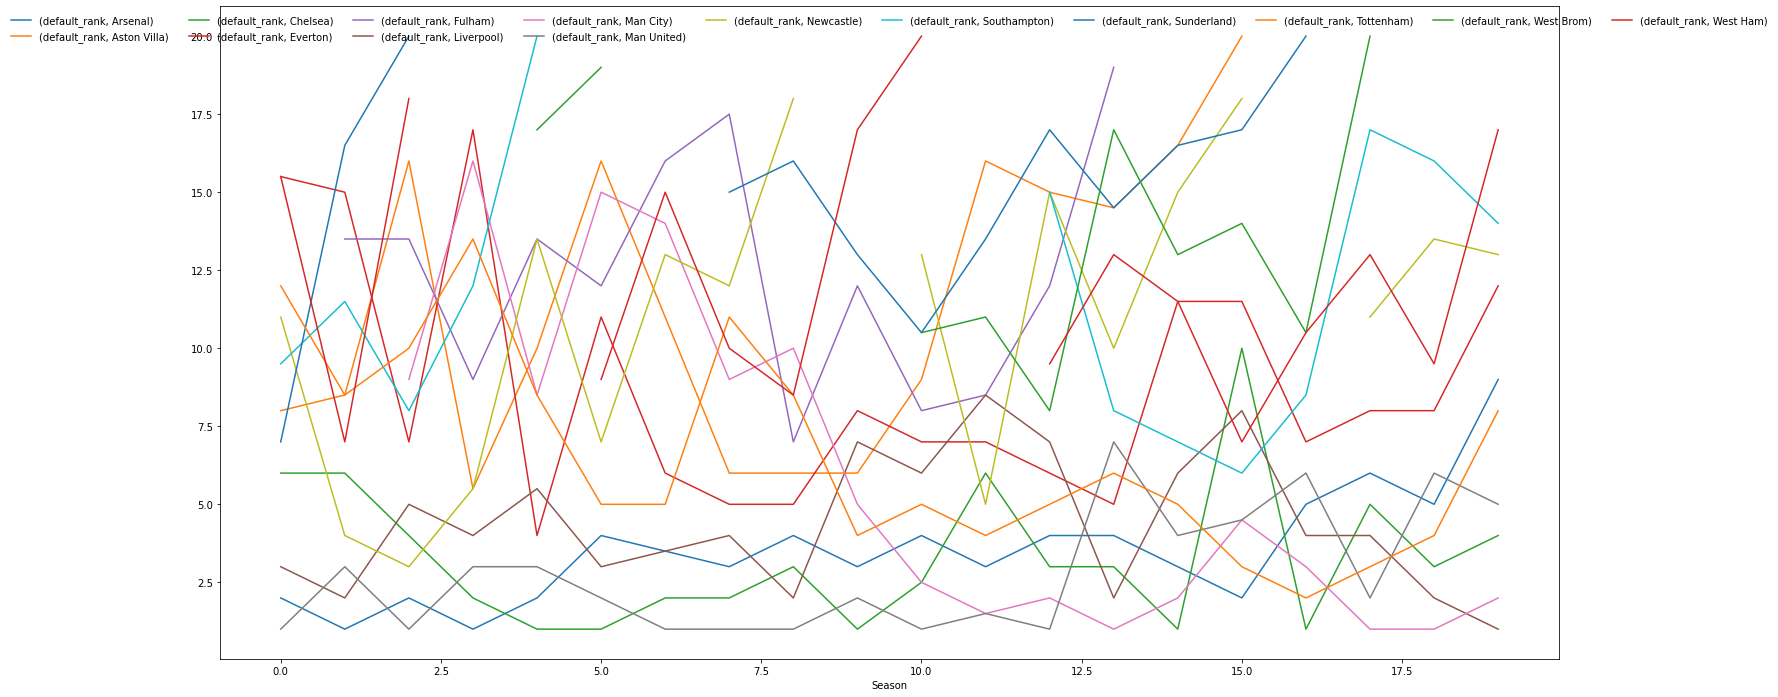

In [117]:
plt.figure()
srt12.plot(figsize=(24, 12))
plt.legend(loc='upper center', frameon=False, ncol=10)

In [118]:
ss.sort_values(by=['Season','Total_team_scores_per_season'], ascending=[True,False], inplace=True)

In [119]:
ss

Total_team_scores_per_season  default_rank
Season HomeTeam                                               
0.0    Man United                           80.0           1.0
       Arsenal                              70.0           2.0
       Liverpool                            69.0           3.0
       Leeds                                68.0           4.0
       Ipswich                              66.0           5.0
...                                          ...           ...
19.0   Bournemouth                          27.0          17.0
       Watford                              27.0          17.0
       West Ham                             27.0          17.0
       Aston Villa                          25.0          19.0
       Norwich                              21.0          20.0

[400 rows x 2 columns]

In [49]:
#ss.to_csv('ss.csv')

In [120]:
pd.DataFrame(df.groupby(['Season','HomeTeam'])['Home_score'].sum().unstack(0) + df.groupby(['Season','AwayTeam'])['Away_score'].sum().unstack(0))

Season,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0
HomeTeam,,,,,,,,,,,,,,,,,,,,
Arsenal,70.0,87.0,78.0,90.0,83.0,67.0,68.0,83.0,72.0,75.0,68.0,70.0,73.0,79.0,75.0,71.0,75.0,63.0,70.0,40.0
Aston Villa,54.0,50.0,45.0,56.0,47.0,42.0,50.0,60.0,62.0,64.0,48.0,38.0,41.0,38.0,38.0,17.0,NaN,NaN,NaN,25.0
Birmingham,NaN,NaN,48.0,50.0,45.0,34.0,NaN,35.0,NaN,50.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blackburn,NaN,46.0,60.0,44.0,42.0,63.0,52.0,58.0,41.0,50.0,43.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blackpool,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bolton,NaN,40.0,44.0,53.0,58.0,56.0,56.0,37.0,41.0,39.0,46.0,36.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bournemouth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.0,46.0,44.0,45.0,27.0
Bradford,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brighton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.0,36.0,29.0


In [122]:
ss['default_rank'].unstack(0).shape

(43, 20)

In [123]:
ss

Total_team_scores_per_season  default_rank
Season HomeTeam                                               
0.0    Man United                           80.0           1.0
       Arsenal                              70.0           2.0
       Liverpool                            69.0           3.0
       Leeds                                68.0           4.0
       Ipswich                              66.0           5.0
...                                          ...           ...
19.0   Bournemouth                          27.0          17.0
       Watford                              27.0          17.0
       West Ham                             27.0          17.0
       Aston Villa                          25.0          19.0
       Norwich                              21.0          20.0

[400 rows x 2 columns]

In [124]:
df.groupby(['Season'])['HomeTeam'].nunique()

Season
0.0     20
1.0     20
2.0     20
3.0     20
4.0     20
5.0     20
6.0     20
7.0     20
8.0     20
9.0     20
10.0    20
11.0    20
12.0    20
13.0    20
14.0    20
15.0    20
16.0    20
17.0    20
18.0    20
19.0    20
Name: HomeTeam, dtype: int64

In [125]:
df.groupby(['Season'])['AwayTeam'].nunique()

Season
0.0     20
1.0     20
2.0     20
3.0     20
4.0     20
5.0     20
6.0     20
7.0     20
8.0     20
9.0     20
10.0    20
11.0    20
12.0    20
13.0    20
14.0    20
15.0    20
16.0    20
17.0    20
18.0    20
19.0    20
Name: AwayTeam, dtype: int64

In [126]:
ate = pd.DataFrame(df[['Crowd_Attendance','Final_result']])

In [55]:
#ate.reset_index(inplace=True)

In [127]:
ate

,Crowd_Attendance,Final_result
0,20043.0,1.0
1,34914.0,1.0
2,20624.0,3.0
3,27223.0,2.0
4,40010.0,1.0
...,...,...
7503,NaN,3.0
7505,NaN,2.0
7507,NaN,1.0
7506,NaN,1.0


In [57]:
#ate.sort_values(by=['Crowd_Attendance'], ascending=[True], inplace=True)

In [128]:
ate['bins_spd'] = pd.qcut(ate['Crowd_Attendance'], 5, duplicates= 'drop')

In [129]:
ate.head()

,Crowd_Attendance,Final_result,bins_spd
0,20043.0,1.0,"(14650.999, 22224.8]"
1,34914.0,1.0,"(29266.6, 35243.2]"
2,20624.0,3.0,"(14650.999, 22224.8]"
3,27223.0,2.0,"(22224.8, 29266.6]"
4,40010.0,1.0,"(35243.2, 41602.0]"


In [130]:
ate['bins_spd'].value_counts()

(41602.0, 67683.0]      152
(35243.2, 41602.0]      152
(22224.8, 29266.6]      152
(14650.999, 22224.8]    152
(29266.6, 35243.2]      151
Name: bins_spd, dtype: int64

In [131]:
ate.groupby(['bins_spd','Final_result']).count()

Crowd_Attendance
bins_spd             Final_result                  
(14650.999, 22224.8] 1.0                         59
                     2.0                         45
                     3.0                         48
(22224.8, 29266.6]   1.0                         63
                     2.0                         44
                     3.0                         45
(29266.6, 35243.2]   1.0                         58
                     2.0                         39
                     3.0                         54
(35243.2, 41602.0]   1.0                         82
                     2.0                         39
                     3.0                         31
(41602.0, 67683.0]   1.0                         87
                     2.0                         34
                     3.0                         31

In [132]:
ate['Crowd_Attendance'].value_counts(dropna=False)

NaN        6749
20043.0      17
20451.0       5
36062.0       4
40055.0       3
           ... 
47437.0       1
26022.0       1
38026.0       1
44363.0       1
15232.0       1
Name: Crowd_Attendance, Length: 711, dtype: int64

In [133]:
#ate.groupby(['bins_spd','Final_result']).count().plot(x='bins_spd', y='Final_result', kind='bar', stacked=True)

In [134]:
df['Corners_ratio']= df['Home_Corners']/(df['Away_Corners'] +df['Home_Corners'])
cor=pd.DataFrame(df[['Corners_ratio', 'Final_result']] )

In [135]:
cor

,Corners_ratio,Final_result
0,0.500000,1.0
1,0.500000,1.0
2,0.666667,3.0
3,0.384615,2.0
4,0.600000,1.0
...,...,...
7503,0.384615,3.0
7505,0.375000,2.0
7507,0.153846,1.0
7506,0.857143,1.0


In [136]:
filt= df['Corners_ratio'].isna()==True
df.loc[filt]

,Date,HomeTeam,AwayTeam,Final_Home_goals,Final_Away_goals,Half_Time_Home_Goals,Half_Time_Away_Goals,Half_Time_Result,Crowd_Attendance,Referee,Home_Shots,Away_Shots,Home_Shots_Target,Away_Shots_Target,Home_Woodwork,Away_Woodwork,Home_Corners,Away_Corners,Home_Fouls,Away_Fouls,Home_Offsides,Away_Offsides,Home_Yellow_Cards,Away_Yellow_Cards,Home_Red_Cards,Away_Red_Cards,Home_Bookings_Points,Away_Bookings_Points,GBH,GBD,GBA,IWH,IWD,IWA,LBH,LBD,LBA,SBH,SBD,SBA,WHH,WHD,WHA,SYH,SYD,SYA,B365H,B365D,B365A,SOH,SOD,SOA,GB>2.5,GB<2.5,B365>2.5,B365<2.5,GBAHH,GBAHA,GBAH,LBAHH,LBAHA,LBAH,B365AHH,B365AHA,B365AH,BWH,BWD,BWA,SJH,SJD,SJA,VCH,VCD,VCA,Bb1X2,BbMxH,BbAvH,BbMxD,BbAvD,BbMxA,BbAvA,BbOU,BbMx>2.5,BbAv>2.5,BbMx<2.5,BbAv<2.5,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,BSH,BSD,BSA,PSH,PSD,PSA,PSCH,PSCD,PSCA,Time,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season,Final_result,Winner,Home_score,Away_score,Corners_ratio
3816,2010-08-21,Wigan,Chelsea,0.0,6.0,0.0,1.0,3,NaN,M Dean,17.0,10.0,12.0,8.0,NaN,NaN,0.0,0.0,12.0,7.0,NaN,NaN,1.0,2.0,0.0,0.0,NaN,NaN,12.0,5.25,1.25,9.0,4.9,1.28,12.0,5.5,1.25,12.0,5.5,1.2,12.0,5.5,1.25,NaN,NaN,NaN,15.0,6.0,1.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.5,5.5,1.22,12.0,5.5,1.25,15.0,6.0,1.22,37.0,15.0,13.11,6.15,5.55,1.28,1.24,25.0,1.68,1.61,2.38,2.2,18.0,1.25,1.9,1.87,2.05,2.0,13.0,5.5,1.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,3.0,Chelsea,0.0,3.0,NaN


In [137]:
cor= cor.loc[cor['Corners_ratio'].isna()==False]

In [138]:
#filt1= df['Final_result']==1
#filt2= (df['Final_result']==2) | (df['Final_result']==3)
#df.loc[filt1,'BB']= 1
#df.loc[filt2,'BB']= 0

In [139]:
df.head()

,Date,HomeTeam,AwayTeam,Final_Home_goals,Final_Away_goals,Half_Time_Home_Goals,Half_Time_Away_Goals,Half_Time_Result,Crowd_Attendance,Referee,Home_Shots,Away_Shots,Home_Shots_Target,Away_Shots_Target,Home_Woodwork,Away_Woodwork,Home_Corners,Away_Corners,Home_Fouls,Away_Fouls,Home_Offsides,Away_Offsides,Home_Yellow_Cards,Away_Yellow_Cards,Home_Red_Cards,Away_Red_Cards,Home_Bookings_Points,Away_Bookings_Points,GBH,GBD,GBA,IWH,IWD,IWA,LBH,LBD,LBA,SBH,SBD,SBA,WHH,WHD,WHA,SYH,SYD,SYA,B365H,B365D,B365A,SOH,SOD,SOA,GB>2.5,GB<2.5,B365>2.5,B365<2.5,GBAHH,GBAHA,GBAH,LBAHH,LBAHA,LBAH,B365AHH,B365AHA,B365AH,BWH,BWD,BWA,SJH,SJD,SJA,VCH,VCD,VCA,Bb1X2,BbMxH,BbAvH,BbMxD,BbAvD,BbMxA,BbAvA,BbOU,BbMx>2.5,BbAv>2.5,BbMx<2.5,BbAv<2.5,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,BSH,BSD,BSA,PSH,PSD,PSA,PSCH,PSCD,PSCA,Time,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season,Final_result,Winner,Home_score,Away_score,Corners_ratio
0,2000-08-19,Charlton,Man City,4.0,0.0,2.0,0.0,1,20043.0,Rob Harris,17.0,8.0,14.0,4.0,2.0,1.0,6.0,6.0,13.0,12.0,8.0,6.0,1.0,2.0,0.0,0.0,10.0,20.0,2.00,3.0,3.2,2.20,2.9,2.7,2.20,3.25,2.75,2.20,3.25,2.88,2.10,3.2,3.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,Charlton,3.0,0.0,0.500000
1,2000-08-19,Chelsea,West Ham,4.0,2.0,1.0,0.0,1,34914.0,Graham Barber,17.0,12.0,10.0,5.0,1.0,0.0,7.0,7.0,19.0,14.0,2.0,3.0,1.0,2.0,0.0,0.0,10.0,20.0,1.47,3.4,5.2,1.60,3.2,4.2,1.50,3.40,6.00,1.50,3.60,6.00,1.44,3.6,6.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,Chelsea,3.0,0.0,0.500000
2,2000-08-19,Coventry,Middlesbrough,1.0,3.0,1.0,1.0,2,20624.0,Barry Knight,6.0,16.0,3.0,9.0,0.0,1.0,8.0,4.0,15.0,21.0,1.0,3.0,5.0,3.0,1.0,0.0,75.0,30.0,2.15,3.0,3.0,2.20,2.9,2.7,2.25,3.20,2.75,2.30,3.20,2.75,2.30,3.2,2.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,Middlesbrough,0.0,3.0,0.666667
3,2000-08-19,Derby,Southampton,2.0,2.0,1.0,2.0,3,27223.0,Andy D'Urso,6.0,13.0,4.0,6.0,0.0,0.0,5.0,8.0,11.0,13.0,0.0,2.0,1.0,1.0,0.0,0.0,10.0,10.0,2.00,3.1,3.2,1.80,3.0,3.5,2.20,3.25,2.75,2.05,3.20,3.20,2.00,3.2,3.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [142]:
cor['intercept'] = 1.0

<ipython-input-142-a6c30f43a2f8>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cor['intercept'] = 1.0


In [143]:
cor

,Corners_ratio,Final_result,intercept
0,0.500000,1.0,1.0
1,0.500000,1.0,1.0
2,0.666667,3.0,1.0
3,0.384615,2.0,1.0
4,0.600000,1.0,1.0
...,...,...,...
7503,0.384615,3.0,1.0
7505,0.375000,2.0,1.0
7507,0.153846,1.0,1.0
7506,0.857143,1.0,1.0


In [72]:
R= cor['Final_result']
C=cor[['Corners_ratio','intercept']]

In [73]:
#C= C.values.reshape(-1, 1)
#R= R.values.reshape(0, 1)

In [74]:
C.shape

(7507, 2)

In [75]:
R.shape

(7507,)

In [76]:
logit = sm.MNLogit(R, C)

In [77]:
res = logit.fit()

Optimization terminated successfully.
         Current function value: 1.058991
         Iterations 5


In [78]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:           Final_result   No. Observations:                 7507
Model:                        MNLogit   Df Residuals:                     7503
Method:                           MLE   Df Model:                            2
Date:                Mon, 06 Jul 2020   Pseudo R-squ.:                0.001873
Time:                        11:12:09   Log-Likelihood:                -7949.8
converged:                       True   LL-Null:                       -7964.8
Covariance Type:            nonrobust   LLR p-value:                 3.310e-07
==================================================================================
Final_result=2       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Corners_ratio     -0.0816      0.137     -0.594      0.553      -0.351       0.188
intercept         -0.5637      0.083     -6.790      0.000      -0.726      -0.401
----------------------------------------------------------------------------------
Final_result=3       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Corners_ratio     -0.6950      0.132     -5.262      0.000      -0.954      -0.436
intercept         -0.1088      0.078     -1.398      0.162      -0.261       0.044
==================================================================================
"""

In [79]:
res.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: MNLogit
=================================================================
Model:              MNLogit          Pseudo R-squared: 0.002     
Dependent Variable: Final_result     AIC:              15907.6902
Date:               2020-07-06 11:12 BIC:              15935.3845
No. Observations:   7507             Log-Likelihood:   -7949.8   
Df Model:           2                LL-Null:          -7964.8   
Df Residuals:       7503             LLR p-value:      3.3101e-07
Converged:          1.0000           Scale:            1.0000    
No. Iterations:     5.0000                                       
----------------------------------------------------------------
Final_result = 0  Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
----------------------------------------------------------------
  Corners_ratio  -0.0816   0.1375 -0.5936 0.5528 -0.3510  0.1878
      intercept  -0.5637   0.0830 -6.7899 0.0000 -0.7265 -0.4010
----------------------------------------------------------------
Final_result = 1  Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
----------------------------------------------------------------
  Corners_ratio  -0.6950   0.1321 -5.2620 0.0000 -0.9538 -0.4361
      intercept  -0.1088   0.0778 -1.3981 0.1621 -0.2613  0.0437
=================================================================

"""

In [80]:
df['Referee'].value_counts(dropna=False)

M Dean          473
M Atkinson      400
A Marriner      328
P Dowd          301
H Webb          296
               ... 
 H Webb           1
D Gallaghe        1
I Williamson      1
F Taylor          1
Ian Harris        1
Name: Referee, Length: 169, dtype: int64

In [81]:
df.head(5)

,Date,HomeTeam,AwayTeam,Final_Home_goals,Final_Away_goals,Half_Time_Home_Goals,Half_Time_Away_Goals,Half_Time_Result,Crowd_Attendance,Referee,Home_Shots,Away_Shots,Home_Shots_Target,Away_Shots_Target,Home_Woodwork,Away_Woodwork,Home_Corners,Away_Corners,Home_Fouls,Away_Fouls,Home_Offsides,Away_Offsides,Home_Yellow_Cards,Away_Yellow_Cards,Home_Red_Cards,Away_Red_Cards,Home_Bookings_Points,Away_Bookings_Points,GBH,GBD,GBA,IWH,IWD,IWA,LBH,LBD,LBA,SBH,SBD,SBA,WHH,WHD,WHA,SYH,SYD,SYA,B365H,B365D,B365A,SOH,SOD,SOA,GB>2.5,GB<2.5,B365>2.5,B365<2.5,GBAHH,GBAHA,GBAH,LBAHH,LBAHA,LBAH,B365AHH,B365AHA,B365AH,BWH,BWD,BWA,SJH,SJD,SJA,VCH,VCD,VCA,Bb1X2,BbMxH,BbAvH,BbMxD,BbAvD,BbMxA,BbAvA,BbOU,BbMx>2.5,BbAv>2.5,BbMx<2.5,BbAv<2.5,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,BSH,BSD,BSA,PSH,PSD,PSA,PSCH,PSCD,PSCA,Time,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season,Final_result,Winner,Home_score,Away_score,Corners_ratio
0,2000-08-19,Charlton,Man City,4.0,0.0,2.0,0.0,1,20043.0,Rob Harris,17.0,8.0,14.0,4.0,2.0,1.0,6.0,6.0,13.0,12.0,8.0,6.0,1.0,2.0,0.0,0.0,10.0,20.0,2.00,3.0,3.2,2.20,2.9,2.7,2.20,3.25,2.75,2.20,3.25,2.88,2.10,3.2,3.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,Charlton,3.0,0.0,0.500000
1,2000-08-19,Chelsea,West Ham,4.0,2.0,1.0,0.0,1,34914.0,Graham Barber,17.0,12.0,10.0,5.0,1.0,0.0,7.0,7.0,19.0,14.0,2.0,3.0,1.0,2.0,0.0,0.0,10.0,20.0,1.47,3.4,5.2,1.60,3.2,4.2,1.50,3.40,6.00,1.50,3.60,6.00,1.44,3.6,6.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,Chelsea,3.0,0.0,0.500000
2,2000-08-19,Coventry,Middlesbrough,1.0,3.0,1.0,1.0,2,20624.0,Barry Knight,6.0,16.0,3.0,9.0,0.0,1.0,8.0,4.0,15.0,21.0,1.0,3.0,5.0,3.0,1.0,0.0,75.0,30.0,2.15,3.0,3.0,2.20,2.9,2.7,2.25,3.20,2.75,2.30,3.20,2.75,2.30,3.2,2.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,Middlesbrough,0.0,3.0,0.666667
3,2000-08-19,Derby,Southampton,2.0,2.0,1.0,2.0,3,27223.0,Andy D'Urso,6.0,13.0,4.0,6.0,0.0,0.0,5.0,8.0,11.0,13.0,0.0,2.0,1.0,1.0,0.0,0.0,10.0,10.0,2.00,3.1,3.2,1.80,3.0,3.5,2.20,3.25,2.75,2.05,3.20,3.20,2.00,3.2,3.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [82]:
df['Away_Bookings_Points'].value_counts(dropna=False)

NaN      6748
10.0      207
20.0      195
30.0      115
0.0       115
40.0       43
55.0       18
35.0       15
45.0       15
50.0       15
65.0        8
25.0        4
70.0        3
75.0        2
60.0        2
100.0       1
85.0        1
90.0        1
Name: Away_Bookings_Points, dtype: int64

In [83]:
pd.set_option('display.max_rows', 170)

In [84]:
df.shape[0]- df.count()

Date                       0
HomeTeam                   0
AwayTeam                   0
Final_Home_goals           0
Final_Away_goals           0
Half_Time_Home_Goals       0
Half_Time_Away_Goals       0
Half_Time_Result           0
Crowd_Attendance        6749
Referee                    0
Home_Shots                 0
Away_Shots                 0
Home_Shots_Target          0
Away_Shots_Target          0
Home_Woodwork           6748
Away_Woodwork           6748
Home_Corners               0
Away_Corners               0
Home_Fouls                 0
Away_Fouls                 0
Home_Offsides           6748
Away_Offsides           6748
Home_Yellow_Cards          0
Away_Yellow_Cards          0
Home_Red_Cards             0
Away_Red_Cards             0
Home_Bookings_Points    6748
Away_Bookings_Points    6748
GBH                     2652
GBD                     2652
GBA                     2652
IWH                       18
IWD                       18
IWA                       18
LBH           

In [85]:
df['IWH'].value_counts(dropna=False)

2.20     436
2.10     415
2.00     377
1.90     339
2.30     335
2.40     306
1.80     275
2.50     226
1.70     198
1.85     198
1.75     190
1.40     173
1.60     170
2.60     154
1.25     148
1.50     148
1.45     144
1.65     144
1.55     142
1.35     138
1.30     133
1.20     117
2.70     116
2.90      86
3.80      81
1.22      73
3.30      72
3.60      72
3.20      71
4.00      70
1.27      69
2.80      67
5.00      66
3.10      63
2.55      62
4.20      60
1.33      59
2.65      55
4.40      51
1.17      50
2.75      48
3.00      47
4.50      47
1.15      45
4.80      42
5.40      42
2.35      39
4.30      38
4.60      37
1.37      36
3.50      35
7.00      35
5.50      34
6.50      34
2.25      30
1.12      28
1.95      28
2.05      28
6.00      27
4.70      27
2.15      26
2.85      25
5.60      25
7.50      24
3.40      24
3.70      24
2.95      19
6.10      18
5.30      18
NaN       18
6.20      17
7.30      17
8.00      17
5.10      15
1.42      14
2.45      13
4.90      12

In [86]:
df['WHH'].value_counts(dropna=False)

2.500     275
2.100     247
2.300     220
2.000     219
2.250     218
2.200     215
1.800     184
1.830     179
2.400     179
2.620     175
1.440     165
2.150     156
1.570     147
1.400     134
1.950     133
1.900     132
2.050     131
1.360     125
6.000     124
1.250     123
5.500     122
5.000     117
1.500     116
NaN       114
1.910     114
1.720     110
1.330     107
1.220     106
2.800     101
1.530      97
4.500      95
1.200      95
3.000      92
1.300      89
2.700      86
2.600      84
3.100      82
4.000      82
2.750      80
1.660      80
2.370      75
1.610      74
7.000      74
3.200      72
3.750      72
1.730      70
1.620      70
1.700      69
1.290      67
1.750      67
2.380      65
4.330      62
1.670      62
6.500      61
3.500      61
1.850      59
3.400      53
2.900      53
8.000      51
4.200      49
1.280      46
1.170      44
3.300      44
3.600      39
1.140      38
1.600      29
4.800      29
3.800      25
2.450      24
9.000      23
10.000     23
1.160 

In [87]:
Inter= pd.DataFrame(df[['IWH','IWD','IWA']])

In [88]:
Inter['intercept'] = 1.0

In [89]:
Inter['Final_result']=df['Final_result']

In [90]:
filt= Inter['IWD'].isna()==True
Inter.loc[filt]

,IWH,IWD,IWA,intercept,Final_result
694,NaN,NaN,NaN,1.0,1.0
739,NaN,NaN,NaN,1.0,2.0
918,NaN,NaN,NaN,1.0,3.0
1117,NaN,NaN,NaN,1.0,3.0
1126,NaN,NaN,NaN,1.0,2.0
1138,NaN,NaN,NaN,1.0,3.0
1137,NaN,NaN,NaN,1.0,3.0
1136,NaN,NaN,NaN,1.0,3.0
1135,NaN,NaN,NaN,1.0,1.0
1139,NaN,NaN,NaN,1.0,2.0


In [91]:
Inter= Inter.loc[Inter['IWD'].isna()==False]

In [92]:
Inter.head(20)

,IWH,IWD,IWA,intercept,Final_result
0,2.20,2.9,2.70,1.0,1.0
1,1.60,3.2,4.20,1.0,1.0
2,2.20,2.9,2.70,1.0,3.0
3,1.80,3.0,3.50,1.0,2.0
4,1.55,3.3,4.50,1.0,1.0
5,2.30,2.9,2.50,1.0,2.0
6,1.25,4.3,8.00,1.0,1.0
7,2.90,2.9,2.10,1.0,1.0
8,1.50,3.4,4.70,1.0,1.0
9,1.45,3.5,5.00,1.0,1.0


In [93]:
R= Inter['Final_result']
C= Inter[['IWH', 'IWD', 'IWA','intercept']]

In [94]:
logit = sm.MNLogit(R, C)

In [95]:
res = logit.fit()

Optimization terminated successfully.
         Current function value: 0.968067
         Iterations 6


In [96]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:           Final_result   No. Observations:                 7490
Model:                        MNLogit   Df Residuals:                     7482
Method:                           MLE   Df Model:                            6
Date:                Mon, 06 Jul 2020   Pseudo R-squ.:                 0.08740
Time:                        11:12:10   Log-Likelihood:                -7250.8
converged:                       True   LL-Null:                       -7945.2
Covariance Type:            nonrobust   LLR p-value:                6.505e-297
==================================================================================
Final_result=2       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
IWH                0.1702      0.066      2.573      0.010       0.041       0.300
IWD               -0.0554      0.154     -0.361      0.718      -0.356       0.246
IWA               -0.1393      0.054     -2.568      0.010      -0.246      -0.033
intercept         -0.1867      0.248     -0.753      0.452      -0.673       0.300
----------------------------------------------------------------------------------
Final_result=3       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
IWH                0.4366      0.072      6.105      0.000       0.296       0.577
IWD                0.0244      0.175      0.140      0.889      -0.318       0.367
IWA               -0.2748      0.064     -4.318      0.000      -0.399      -0.150
intercept         -0.6459      0.278     -2.322      0.020      -1.191      -0.101
==================================================================================
"""

In [97]:
Inter['bins_spd1'] = pd.qcut(Inter['IWH'], 5, duplicates= 'drop')

In [98]:
Inter.groupby(['bins_spd1','Final_result']).agg({'Final_result':'count'}) 

Final_result
bins_spd1                  Final_result              
(1.0490000000000002, 1.55] 1.0                   1157
                           2.0                    283
                           3.0                    134
(1.55, 1.9]                1.0                    875
                           2.0                    397
                           3.0                    289
(1.9, 2.3]                 1.0                    721
                           2.0                    493
                           3.0                    470
(2.3, 2.9]                 1.0                    413
                           2.0                    400
                           3.0                    384
(2.9, 20.0]                1.0                    315
                           2.0                    316
                           3.0                    843

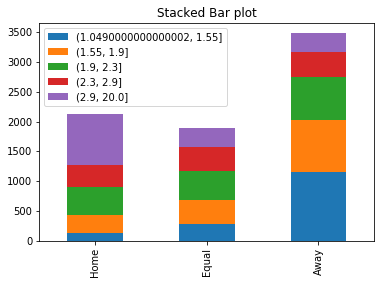

In [99]:
# Stacked barplot with pandas
Home = Inter.loc[Inter['Final_result']==3]['bins_spd1'].value_counts()
Equal= Inter.loc[Inter['Final_result']==2]['bins_spd1'].value_counts()
Away = Inter.loc[Inter['Final_result']==1]['bins_spd1'].value_counts()
Inter_plot  = pd.DataFrame([Home,Equal,Away])
Inter_plot.index=['Home','Equal','Away']
# Plot
Inter_plot.plot(kind='bar',stacked=True, title='Stacked Bar plot')

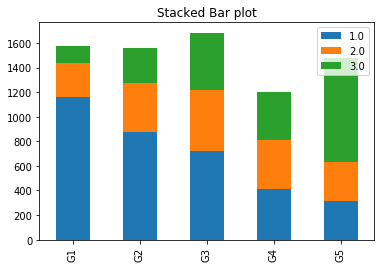

In [100]:
G1 = Inter.loc[Inter['bins_spd1']==pd.Interval(1.0490000000000002, 1.55, closed='right')]['Final_result'].value_counts()
G2 = Inter.loc[Inter['bins_spd1']==pd.Interval(1.55, 1.9, closed='right')]['Final_result'].value_counts()
G3 = Inter.loc[Inter['bins_spd1']==pd.Interval(1.9, 2.3, closed='right')]['Final_result'].value_counts()
G4 = Inter.loc[Inter['bins_spd1']==pd.Interval(2.3, 2.9, closed='right')]['Final_result'].value_counts()
G5 = Inter.loc[Inter['bins_spd1']==pd.Interval(2.9, 20.0, closed='right')]['Final_result'].value_counts()
Inter_plot  = pd.DataFrame([G1,G2,G3,G4,G5])
Inter_plot.index=['G1','G2','G3','G4','G5']
# Plot
Inter_plot.plot(kind='bar',stacked=True, title='Stacked Bar plot')

In [101]:
Inter['bins_spd2'] = pd.qcut(Inter['IWD'], 5, duplicates= 'drop')
Inter['bins_spd2'].value_counts()

(3.1, 3.3]      2171
(2.499, 3.1]    1775
(3.9, 12.0]     1484
(3.45, 3.9]     1390
(3.3, 3.45]      670
Name: bins_spd2, dtype: int64

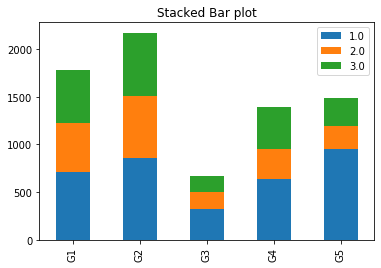

In [102]:
G1 = Inter.loc[Inter['bins_spd2']==pd.Interval(2.499, 3.1, closed='right')]['Final_result'].value_counts()
G2 = Inter.loc[Inter['bins_spd2']==pd.Interval(3.1, 3.3, closed='right')]['Final_result'].value_counts()
G3 = Inter.loc[Inter['bins_spd2']==pd.Interval(3.3, 3.45, closed='right')]['Final_result'].value_counts()
G4 = Inter.loc[Inter['bins_spd2']==pd.Interval(3.45, 3.9, closed='right')]['Final_result'].value_counts()
G5 = Inter.loc[Inter['bins_spd2']==pd.Interval(3.9, 12.0, closed='right')]['Final_result'].value_counts()
Inter_plot  = pd.DataFrame([G1,G2,G3,G4,G5])
Inter_plot.index=['G1','G2','G3','G4','G5']
# Plot
Inter_plot.plot(kind='bar',stacked=True, title='Stacked Bar plot')

In [103]:
Inter['bins_spd3'] = pd.qcut(Inter['IWA'], 5, duplicates= 'drop')
Inter['bins_spd3'].value_counts()

(1.1190000000000002, 2.3]    1640
(5.3, 29.0]                  1495
(2.9, 3.6]                   1487
(3.6, 5.3]                   1440
(2.3, 2.9]                   1428
Name: bins_spd3, dtype: int64

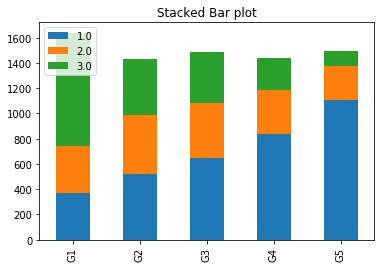

In [104]:
G1 = Inter.loc[Inter['bins_spd3']==pd.Interval(1.1190000000000002, 2.3, closed='right')]['Final_result'].value_counts()
G2 = Inter.loc[Inter['bins_spd3']==pd.Interval(2.3, 2.9, closed='right')]['Final_result'].value_counts()
G3 = Inter.loc[Inter['bins_spd3']==pd.Interval(2.9, 3.6, closed='right')]['Final_result'].value_counts()
G4 = Inter.loc[Inter['bins_spd3']==pd.Interval(3.6, 5.3, closed='right')]['Final_result'].value_counts()
G5 = Inter.loc[Inter['bins_spd3']==pd.Interval(5.3, 29.0, closed='right')]['Final_result'].value_counts()
Inter_plot  = pd.DataFrame([G1,G2,G3,G4,G5])
Inter_plot.index=['G1','G2','G3','G4','G5']
# Plot
Inter_plot.plot(kind='bar',stacked=True, title='Stacked Bar plot')

In [105]:
Inter2= pd.DataFrame(df[['WHH','WHD','WHA']])

In [106]:
Inter2['intercept'] = 1.0

In [107]:
Inter2['Final_result']=df['Final_result']

In [108]:
Inter2= Inter2.loc[Inter2['WHH'].isna()==False]

In [109]:
Inter2

,WHH,WHD,WHA,intercept,Final_result
0,2.10,3.20,3.10,1.0,1.0
1,1.44,3.60,6.50,1.0,1.0
2,2.30,3.20,2.62,1.0,3.0
3,2.00,3.20,3.20,1.0,2.0
4,1.61,3.50,4.50,1.0,1.0
...,...,...,...,...,...
7503,1.67,3.80,5.25,1.0,3.0
7505,2.70,3.25,2.70,1.0,2.0
7507,5.00,4.20,1.63,1.0,1.0
7506,1.85,3.70,4.20,1.0,1.0


In [110]:
R= Inter2['Final_result']
C= Inter2[['WHH', 'WHD', 'WHA','intercept']]

In [111]:
logit = sm.MNLogit(R, C)

In [112]:
res = logit.fit()

Optimization terminated successfully.
         Current function value: 0.969806
         Iterations 6


In [113]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:           Final_result   No. Observations:                 7394
Model:                        MNLogit   Df Residuals:                     7386
Method:                           MLE   Df Model:                            6
Date:                Mon, 06 Jul 2020   Pseudo R-squ.:                 0.08620
Time:                        11:12:11   Log-Likelihood:                -7170.7
converged:                       True   LL-Null:                       -7847.2
Covariance Type:            nonrobust   LLR p-value:                3.933e-289
==================================================================================
Final_result=2       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
WHH                0.1515      0.043      3.520      0.000       0.067       0.236
WHD               -0.0787      0.106     -0.741      0.459      -0.287       0.129
WHA               -0.1126      0.032     -3.573      0.000      -0.174      -0.051
intercept         -0.1417      0.217     -0.653      0.514      -0.567       0.284
----------------------------------------------------------------------------------
Final_result=3       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
WHH                0.3940      0.044      8.907      0.000       0.307       0.481
WHD               -0.0352      0.122     -0.289      0.773      -0.274       0.204
WHA               -0.2072      0.037     -5.609      0.000      -0.280      -0.135
intercept         -0.5628      0.248     -2.272      0.023      -1.048      -0.077
==================================================================================
"""

In [114]:
Inter2['bins_spd1'] = pd.qcut(Inter2['WHH'], 5, duplicates= 'drop')

In [115]:
Inter2['bins_spd1'].value_counts()

(1.91, 2.3]                   1539
(1.53, 1.91]                  1495
(1.0490000000000002, 1.53]    1493
(2.3, 3.1]                    1440
(3.1, 21.0]                   1427
Name: bins_spd1, dtype: int64

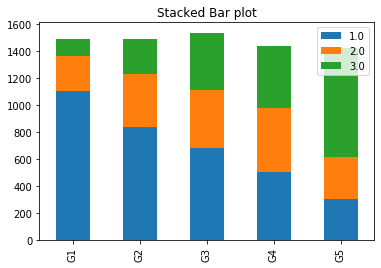

In [116]:
G1 = Inter2.loc[Inter2['bins_spd1']==pd.Interval(1.0490000000000002, 1.53, closed='right')]['Final_result'].value_counts()
G2 = Inter2.loc[Inter2['bins_spd1']==pd.Interval(1.53, 1.91, closed='right')]['Final_result'].value_counts()
G3 = Inter2.loc[Inter2['bins_spd1']==pd.Interval(1.91, 2.3, closed='right')]['Final_result'].value_counts()
G4 = Inter2.loc[Inter2['bins_spd1']==pd.Interval(2.3, 3.1, closed='right')]['Final_result'].value_counts()
G5 = Inter2.loc[Inter2['bins_spd1']==pd.Interval(3.1, 21.0, closed='right')]['Final_result'].value_counts()
Inter2_plot  = pd.DataFrame([G1,G2,G3,G4,G5])
Inter2_plot.index=['G1','G2','G3','G4','G5']
# Plot
Inter2_plot.plot(kind='bar',stacked=True, title='Stacked Bar plot')

In [117]:
df['BbMx>2.5'].value_counts()

2.200    215
2.250    197
2.100    157
2.050    133
2.150    127
2.000    114
2.300    112
1.950    103
1.750    102
1.800    101
1.850     97
1.910     92
2.080     81
2.020     76
1.900     75
2.110     74
2.040     70
2.120     70
1.670     69
2.060     68
1.830     67
2.350     67
2.400     66
1.860     65
1.700     63
1.960     63
2.140     63
2.180     61
1.880     58
1.650     58
1.930     58
1.770     58
2.210     57
1.870     57
2.160     56
1.980     55
2.190     54
1.920     51
2.170     51
1.730     50
2.280     47
2.010     46
1.760     46
2.130     45
2.090     44
1.820     43
1.600     43
1.970     43
1.680     42
2.070     42
1.810     42
2.220     41
1.890     40
2.260     40
1.500     40
1.620     39
2.380     39
2.230     39
1.720     37
2.030     36
1.570     36
1.740     36
1.550     35
1.780     35
1.840     34
1.790     33
2.310     33
1.940     33
1.530     32
1.990     32
1.560     32
1.710     31
2.240     30
2.450     30
2.270     29
2.500     29
1.690     28

In [118]:
Inter3= pd.DataFrame(df[['BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5']])

In [119]:
Inter3['intercept'] = 1.0

In [120]:
Inter3['Final_result']=df['Final_result']

In [121]:
Inter3= Inter3.loc[Inter3['BbMx>2.5'].isna()==False]

In [122]:
Inter3

,BbMx>2.5,BbAv>2.5,BbMx<2.5,BbAv<2.5,intercept,Final_result
1905,2.10,1.96,1.84,1.75,1.0,3.0
1907,2.25,2.02,1.80,1.71,1.0,1.0
1906,2.12,1.98,1.82,1.74,1.0,3.0
1904,2.23,2.02,1.80,1.71,1.0,2.0
1903,2.10,1.94,1.90,1.77,1.0,2.0
...,...,...,...,...,...,...
7215,1.75,1.70,2.26,2.16,1.0,2.0
7214,1.80,1.75,2.17,2.08,1.0,3.0
7213,1.60,1.54,2.59,2.45,1.0,1.0
7212,1.61,1.57,2.55,2.39,1.0,3.0


In [123]:
R= Inter3['Final_result']
C= Inter3[['BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5','intercept']]

In [124]:
logit = sm.MNLogit(R, C)

In [125]:
res = logit.fit()

Optimization terminated successfully.
         Current function value: 1.043624
         Iterations 6


In [126]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:           Final_result   No. Observations:                 5320
Model:                        MNLogit   Df Residuals:                     5310
Method:                           MLE   Df Model:                            8
Date:                Mon, 06 Jul 2020   Pseudo R-squ.:                 0.01475
Time:                        11:12:12   Log-Likelihood:                -5552.1
converged:                       True   LL-Null:                       -5635.2
Covariance Type:            nonrobust   LLR p-value:                 8.044e-32
==================================================================================
Final_result=2       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
BbMx>2.5          -3.1566      1.002     -3.149      0.002      -5.121      -1.192
BbAv>2.5           2.3583      1.118      2.110      0.035       0.167       4.549
BbMx<2.5          -1.9809      1.085     -1.826      0.068      -4.107       0.145
BbAv<2.5          -0.0015      1.247     -0.001      0.999      -2.446       2.443
intercept          5.2064      1.539      3.383      0.001       2.190       8.223
----------------------------------------------------------------------------------
Final_result=3       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
BbMx>2.5          -0.8317      0.916     -0.908      0.364      -2.626       0.963
BbAv>2.5          -0.0065      1.041     -0.006      0.995      -2.047       2.034
BbMx<2.5          -2.8290      1.018     -2.778      0.005      -4.825      -0.833
BbAv<2.5           1.5760      1.162      1.356      0.175      -0.702       3.854
intercept          3.9019      1.344      2.903      0.004       1.268       6.536
==================================================================================
"""

In [127]:
Inter3['bins_spd1'] = pd.qcut(Inter3['BbMx>2.5'], 5, duplicates= 'drop')

In [128]:
Inter3['bins_spd1'].value_counts()

(1.94, 2.1]      1163
(1.239, 1.76]    1093
(2.24, 3.14]     1042
(1.76, 1.94]     1039
(2.1, 2.24]       983
Name: bins_spd1, dtype: int64

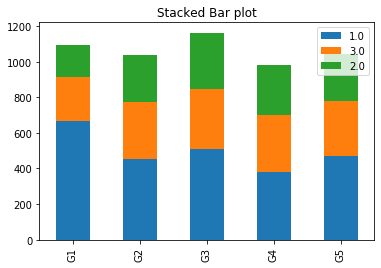

In [129]:
G1 = Inter3.loc[Inter3['bins_spd1']==pd.Interval(1.239, 1.76, closed='right')]['Final_result'].value_counts()
G2 = Inter3.loc[Inter3['bins_spd1']==pd.Interval(1.76, 1.94, closed='right')]['Final_result'].value_counts()
G3 = Inter3.loc[Inter3['bins_spd1']==pd.Interval(1.94, 2.1, closed='right')]['Final_result'].value_counts()
G4 = Inter3.loc[Inter3['bins_spd1']==pd.Interval(2.1, 2.24, closed='right')]['Final_result'].value_counts()
G5 = Inter3.loc[Inter3['bins_spd1']==pd.Interval(2.24, 3.14, closed='right')]['Final_result'].value_counts()
Inter3_plot  = pd.DataFrame([G1,G2,G3,G4,G5])
Inter3_plot.index=['G1','G2','G3','G4','G5']
# Plot
Inter3_plot.plot(kind='bar',stacked=True, title='Stacked Bar plot')

In [144]:
df['Referee'].nunique()

169

In [147]:
df['Referee']

0             Rob Harris
1          Graham Barber
2           Barry Knight
3            Andy D'Urso
4       Dermot Gallagher
              ...       
7503             G Scott
7505              J Moss
7507              M Dean
7506            K Friend
7508            M Oliver
Name: Referee, Length: 7508, dtype: object

In [146]:
df['Referee']= df['Referee'].str.strip()

In [132]:
filt= df['Final_result']==1

In [133]:
df.loc[filt].groupby(['Season','Referee']).agg({'Date':'count'})

Date
Season Referee           
0.0    Alan Wiley       7
       Andy D'Urso     10
       Andy Hall        1
       Barry Knight    10
       Clive Wilkes     3
...                   ...
19.0   P Bankes         3
       P Tierney       10
       S Attwell        2
       S Hooper         4
       T Robinson       1

[408 rows x 1 columns]

In [134]:
# the same as: df.groupby(['Season','Referee'])['Date'].agg('count')
df.groupby(['Season','Referee']).agg({'Date':'count'})

Date
Season Referee           
0.0    Alan Wiley      23
       Andy D'Urso     19
       Andy Hall        1
       Barry Knight    16
       Clive Wilkes     9
...                   ...
19.0   R Jones          1
       S Attwell       15
       S Hooper         9
       S Scott          1
       T Robinson       1

[443 rows x 1 columns]

In [135]:
df.head()

,Date,HomeTeam,AwayTeam,Final_Home_goals,Final_Away_goals,Half_Time_Home_Goals,Half_Time_Away_Goals,Half_Time_Result,Crowd_Attendance,Referee,Home_Shots,Away_Shots,Home_Shots_Target,Away_Shots_Target,Home_Woodwork,Away_Woodwork,Home_Corners,Away_Corners,Home_Fouls,Away_Fouls,Home_Offsides,Away_Offsides,Home_Yellow_Cards,Away_Yellow_Cards,Home_Red_Cards,Away_Red_Cards,Home_Bookings_Points,Away_Bookings_Points,GBH,GBD,GBA,IWH,IWD,IWA,LBH,LBD,LBA,SBH,SBD,SBA,WHH,WHD,WHA,SYH,SYD,SYA,B365H,B365D,B365A,SOH,SOD,SOA,GB>2.5,GB<2.5,B365>2.5,B365<2.5,GBAHH,GBAHA,GBAH,LBAHH,LBAHA,LBAH,B365AHH,B365AHA,B365AH,BWH,BWD,BWA,SJH,SJD,SJA,VCH,VCD,VCA,Bb1X2,BbMxH,BbAvH,BbMxD,BbAvD,BbMxA,BbAvA,BbOU,BbMx>2.5,BbAv>2.5,BbMx<2.5,BbAv<2.5,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,BSH,BSD,BSA,PSH,PSD,PSA,PSCH,PSCD,PSCA,Time,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season,Final_result,Winner,Home_score,Away_score,Corners_ratio
0,2000-08-19,Charlton,Man City,4.0,0.0,2.0,0.0,1,20043.0,Rob Harris,17.0,8.0,14.0,4.0,2.0,1.0,6.0,6.0,13.0,12.0,8.0,6.0,1.0,2.0,0.0,0.0,10.0,20.0,2.00,3.0,3.2,2.20,2.9,2.7,2.20,3.25,2.75,2.20,3.25,2.88,2.10,3.2,3.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,Charlton,3.0,0.0,0.500000
1,2000-08-19,Chelsea,West Ham,4.0,2.0,1.0,0.0,1,34914.0,Graham Barber,17.0,12.0,10.0,5.0,1.0,0.0,7.0,7.0,19.0,14.0,2.0,3.0,1.0,2.0,0.0,0.0,10.0,20.0,1.47,3.4,5.2,1.60,3.2,4.2,1.50,3.40,6.00,1.50,3.60,6.00,1.44,3.6,6.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,Chelsea,3.0,0.0,0.500000
2,2000-08-19,Coventry,Middlesbrough,1.0,3.0,1.0,1.0,2,20624.0,Barry Knight,6.0,16.0,3.0,9.0,0.0,1.0,8.0,4.0,15.0,21.0,1.0,3.0,5.0,3.0,1.0,0.0,75.0,30.0,2.15,3.0,3.0,2.20,2.9,2.7,2.25,3.20,2.75,2.30,3.20,2.75,2.30,3.2,2.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,Middlesbrough,0.0,3.0,0.666667
3,2000-08-19,Derby,Southampton,2.0,2.0,1.0,2.0,3,27223.0,Andy D'Urso,6.0,13.0,4.0,6.0,0.0,0.0,5.0,8.0,11.0,13.0,0.0,2.0,1.0,1.0,0.0,0.0,10.0,10.0,2.00,3.1,3.2,1.80,3.0,3.5,2.20,3.25,2.75,2.05,3.20,3.20,2.00,3.2,3.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [136]:
df.loc[filt].groupby(['Season','Referee']).agg({'Date':'count'})/df.groupby(['Season','Referee']).agg({'Date':'count'}) 

Date
Season Referee               
0.0    Alan Wiley    0.304348
       Andy D'Urso   0.526316
       Andy Hall     1.000000
       Barry Knight  0.625000
       Clive Wilkes  0.333333
...                       ...
19.0   R Jones            NaN
       S Attwell     0.133333
       S Hooper      0.444444
       S Scott            NaN
       T Robinson    1.000000

[443 rows x 1 columns]

In [137]:
filt=df['Season']==19
df.loc[filt,'Referee'].value_counts(dropna=False)

M Atkinson    25
M Oliver      23
A Taylor      23
M Dean        22
P Tierney     20
J Moss        20
K Friend      20
C Kavanagh    20
A Marriner    17
C Pawson      15
S Attwell     15
G Scott       14
L Mason       13
D Coote       11
A Madley       9
S Hooper       9
P Bankes       7
R Jones        1
T Robinson     1
D England      1
S Scott        1
O Langford     1
Name: Referee, dtype: int64

In [138]:
filt= (df['Referee']=='R Jones') & (df['Season']==19)
df.loc[filt]

,Date,HomeTeam,AwayTeam,Final_Home_goals,Final_Away_goals,Half_Time_Home_Goals,Half_Time_Away_Goals,Half_Time_Result,Crowd_Attendance,Referee,Home_Shots,Away_Shots,Home_Shots_Target,Away_Shots_Target,Home_Woodwork,Away_Woodwork,Home_Corners,Away_Corners,Home_Fouls,Away_Fouls,Home_Offsides,Away_Offsides,Home_Yellow_Cards,Away_Yellow_Cards,Home_Red_Cards,Away_Red_Cards,Home_Bookings_Points,Away_Bookings_Points,GBH,GBD,GBA,IWH,IWD,IWA,LBH,LBD,LBA,SBH,SBD,SBA,WHH,WHD,WHA,SYH,SYD,SYA,B365H,B365D,B365A,SOH,SOD,SOA,GB>2.5,GB<2.5,B365>2.5,B365<2.5,GBAHH,GBAHA,GBAH,LBAHH,LBAHA,LBAH,B365AHH,B365AHA,B365AH,BWH,BWD,BWA,SJH,SJD,SJA,VCH,VCD,VCA,Bb1X2,BbMxH,BbAvH,BbMxD,BbAvD,BbMxA,BbAvA,BbOU,BbMx>2.5,BbAv>2.5,BbMx<2.5,BbAv<2.5,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,BSH,BSD,BSA,PSH,PSD,PSA,PSCH,PSCD,PSCA,Time,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season,Final_result,Winner,Home_score,Away_score,Corners_ratio
7394,2019-12-21,Brighton,Sheffield United,0.0,1.0,0.0,1.0,3,NaN,R Jones,9.0,7.0,2.0,2.0,NaN,NaN,4.0,3.0,6.0,11.0,NaN,NaN,1.0,3.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,2.2,3.25,3.45,NaN,NaN,NaN,NaN,NaN,NaN,2.2,3.2,3.5,NaN,NaN,NaN,2.2,3.25,3.5,NaN,NaN,NaN,NaN,NaN,2.1,1.72,NaN,NaN,NaN,NaN,NaN,NaN,1.91,2.02,NaN,2.2,3.3,3.4,NaN,NaN,NaN,2.2,3.3,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.24,3.27,3.61,2.22,3.3,3.61,15:00,2.32,3.35,3.7,2.21,3.27,3.52,2.15,1.78,2.21,1.8,2.11,1.73,-0.25,1.92,2.01,1.92,2.04,1.88,1.99,2.1,3.4,3.5,2.15,3.4,3.6,2.35,3.3,3.05,2.15,3.3,3.6,2.15,3.4,3.5,2.35,3.5,3.8,2.17,3.36,3.54,2.0,1.8,2.08,1.84,2.08,1.88,2.01,1.81,-0.25,1.9,2.03,1.9,2.02,1.93,2.05,1.87,2.0,19.0,3.0,Sheffield United,0.0,3.0,0.571429


In [139]:
df.loc[filt].groupby(['Season','Referee']).agg({'Date':'count'})

,,Date
Season,Referee,
19.0,R Jones,1


In [140]:
filt2=(df['Referee']=='R Jones') & (df['Season']==19) & (df['Final_result']==1)

In [141]:
df.loc[filt2].groupby(['Season','Referee']).agg({'Date':'count'}) 

,,Date
Season,Referee,


In [142]:
df.loc[filt2].groupby(['Season','Referee']).agg({'Date':'count'}) /df.loc[filt].groupby(['Season','Referee']).agg({'Date':'count'})

,,Date
Season,Referee,
19.0,R Jones,NaN


we should replace Nan values with zero. there are 2 ways: 1) using a df to store the above columns and then replace the Nan values of a result column with zero. 2) using parenthises and loc function to use the above filt result as a df. 
at this point we just conclud that the referee is important and we should consider that.

In [143]:
df.head(3)

,Date,HomeTeam,AwayTeam,Final_Home_goals,Final_Away_goals,Half_Time_Home_Goals,Half_Time_Away_Goals,Half_Time_Result,Crowd_Attendance,Referee,Home_Shots,Away_Shots,Home_Shots_Target,Away_Shots_Target,Home_Woodwork,Away_Woodwork,Home_Corners,Away_Corners,Home_Fouls,Away_Fouls,Home_Offsides,Away_Offsides,Home_Yellow_Cards,Away_Yellow_Cards,Home_Red_Cards,Away_Red_Cards,Home_Bookings_Points,Away_Bookings_Points,GBH,GBD,GBA,IWH,IWD,IWA,LBH,LBD,LBA,SBH,SBD,SBA,WHH,WHD,WHA,SYH,SYD,SYA,B365H,B365D,B365A,SOH,SOD,SOA,GB>2.5,GB<2.5,B365>2.5,B365<2.5,GBAHH,GBAHA,GBAH,LBAHH,LBAHA,LBAH,B365AHH,B365AHA,B365AH,BWH,BWD,BWA,SJH,SJD,SJA,VCH,VCD,VCA,Bb1X2,BbMxH,BbAvH,BbMxD,BbAvD,BbMxA,BbAvA,BbOU,BbMx>2.5,BbAv>2.5,BbMx<2.5,BbAv<2.5,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,BSH,BSD,BSA,PSH,PSD,PSA,PSCH,PSCD,PSCA,Time,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season,Final_result,Winner,Home_score,Away_score,Corners_ratio
0,2000-08-19,Charlton,Man City,4.0,0.0,2.0,0.0,1,20043.0,Rob Harris,17.0,8.0,14.0,4.0,2.0,1.0,6.0,6.0,13.0,12.0,8.0,6.0,1.0,2.0,0.0,0.0,10.0,20.0,2.00,3.0,3.2,2.2,2.9,2.7,2.20,3.25,2.75,2.2,3.25,2.88,2.10,3.2,3.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,Charlton,3.0,0.0,0.500000
1,2000-08-19,Chelsea,West Ham,4.0,2.0,1.0,0.0,1,34914.0,Graham Barber,17.0,12.0,10.0,5.0,1.0,0.0,7.0,7.0,19.0,14.0,2.0,3.0,1.0,2.0,0.0,0.0,10.0,20.0,1.47,3.4,5.2,1.6,3.2,4.2,1.50,3.40,6.00,1.5,3.60,6.00,1.44,3.6,6.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,Chelsea,3.0,0.0,0.500000
2,2000-08-19,Coventry,Middlesbrough,1.0,3.0,1.0,1.0,2,20624.0,Barry Knight,6.0,16.0,3.0,9.0,0.0,1.0,8.0,4.0,15.0,21.0,1.0,3.0,5.0,3.0,1.0,0.0,75.0,30.0,2.15,3.0,3.0,2.2,2.9,2.7,2.25,3.20,2.75,2.3,3.20,2.75,2.30,3.2,2.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,Middlesbrough,0.0,3.0,0.666667


In [144]:
df.to_csv('df.csv')